In [17]:
#RNN models work with numeric arrays.
import numpy as np #numerical cal/arr
import pandas as pd #read and handle dataset 
import matplotlib.pyplot as plt #graph

from sklearn.preprocessing import MinMaxScaler #Scales data between 0 and 1. -->Normalized data
from sklearn.metrics import mean_squared_error , mean_absolute_error #Measures prediction error.

from tensorflow.keras.models import Sequential #model where layers are added one after another.
from tensorflow.keras.layers import Input,SimpleRNN, Dense #Defines input shape of data

In [2]:
data = pd.read_csv("Electric_Production.csv") #time series dataset of  electric production

In [3]:
data.head()

,DATE,IPG2211A2N
0,1/1/1985,72.5052
1,2/1/1985,70.6720
2,3/1/1985,62.4502
3,4/1/1985,57.4714
4,5/1/1985,55.3151


In [4]:
data.describe()

,IPG2211A2N
count,397.000000
mean,88.847218
std,15.387834
min,55.315100
25%,77.105200
50%,89.779500
75%,100.524400
max,129.404800


In [5]:
data.dtypes

DATE           object
IPG2211A2N    float64
dtype: object

In [6]:
data.columns

Index(['DATE', 'IPG2211A2N'], dtype='object')

In [7]:
#extract the second column from your dataset and Changes array shape into 2D column format
dataset = data.iloc[:,1].values.reshape(-1,1)

In [8]:
scaler = MinMaxScaler(feature_range=(0,1)) #convert data into normalized form (between 0 & 1)
dataset = scaler.fit_transform(dataset)

In [9]:
#creating input sequences
#dataset create input data and target data
def create_dataset(data, time_step=12): #use previous 12 values to predict next month
    X, y = [], [] #inputs (past values) & target outputs (next value)
    
    for i in range(len(data)-time_step): #traverse dataset
        X.append(data[i:i+time_step]) #Stores previous 12 values.
        y.append(data[i+time_step])
        
    return np.array(X), np.array(y) #Convert lists to NumPy arrays

time_step = 12
X, y = create_dataset(dataset, time_step) #func call

In [10]:
#split your time series dataset into training data and testing data.

train_size = int(len(X)*0.8) #Calculates 80% of total samples.

# 80% training , 20% testing
X_train = X[:train_size] #learn patterns
X_test  = X[train_size:] #check prediction accuracy

y_train = y[:train_size]
y_test  = y[train_size:]

print(X_train.shape)
print(X_test.shape)

(308, 12, 1)
(77, 12, 1)


In [11]:
# Input Data → RNN Layer → Dense Output → Prediction --> Build RNN model

model = Sequential() #Creates an empty neural network model.
model.add(Input(shape=(time_step,1))) #Defines input shape

#Processes sequential data one step at a time and remembers previous information.
model.add(SimpleRNN( 
    units=50, # number of units (neurons) in each RNN layer.
    activation='tanh'
))

model.add(Dense(1)) #Dense layer gives final numeric prediction.

model.compile( # compile & prepares model for training.
    optimizer='adam',
    loss='mean_squared_error'
)

In [12]:
# model study the data 100 times ,Each time improves prediction
#train the model.
history = model.fit( 
    X_train,  #Contains past sequences.
    y_train,  #Actual next values.
    epochs=100, #one full pass through training data.
    batch_size=16, #chunk of 16 
    validation_data=(X_test,y_test), #checks performance on unseen test data
    verbose=1
)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0144 - val_loss: 0.0098
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0039 - val_loss: 0.0044
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0028 - val_loss: 0.0034
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0022 - val_loss: 0.0031
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0020 - val_loss: 0.0034
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0018 - val_loss: 0.0037
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0019 - val_loss: 0.0029
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0018 - val_loss: 0.0029
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0028 - val_loss: 0.0102
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0026 - val_loss: 0.0036
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0017 - val_loss: 0.0025
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 

In [13]:
train_predict = model.predict(X_train) #predicts outputs for training data.
test_predict  = model.predict(X_test) 

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


In [14]:
train_predict = scaler.inverse_transform(train_predict) #Training Predictions Back(0-1) to Original Scale
test_predict  = scaler.inverse_transform(test_predict)

y_train_actual = scaler.inverse_transform(y_train) #Convert Actual Values Back
y_test_actual  = scaler.inverse_transform(y_test)

In [18]:
#measure prediction accuracy of your RNN model.
train_mse = mean_squared_error(y_train_actual, train_predict)
test_mse  = mean_squared_error(y_test_actual, test_predict)

train_rmse = np.sqrt(train_mse) # calculate error on training data
test_rmse  = np.sqrt(test_mse) # calculate error on test data

train_mae = mean_absolute_error(y_train_actual, train_predict)
test_mae  = mean_absolute_error(y_test_actual, test_predict)

print("Train MSE :", train_mse)
print("Test MSE  :", test_mse)

print("Train RMSE:", train_rmse) #Lower RMSE = better predictions. (Root Mean Squared Error)
print("Test RMSE :", test_rmse)

print("Train MAE :", train_mae)
print("Test MAE  :", test_mae)
print("Test RMSE :", test_rmse)

Train MSE : 6.4048462371816495
Test MSE  : 12.54244795237709
Train RMSE: 2.5307797686052513
Test RMSE : 3.541531865221191
Train MAE : 1.933455927266703
Test MAE  : 2.5209991287033278
Test RMSE : 3.541531865221191


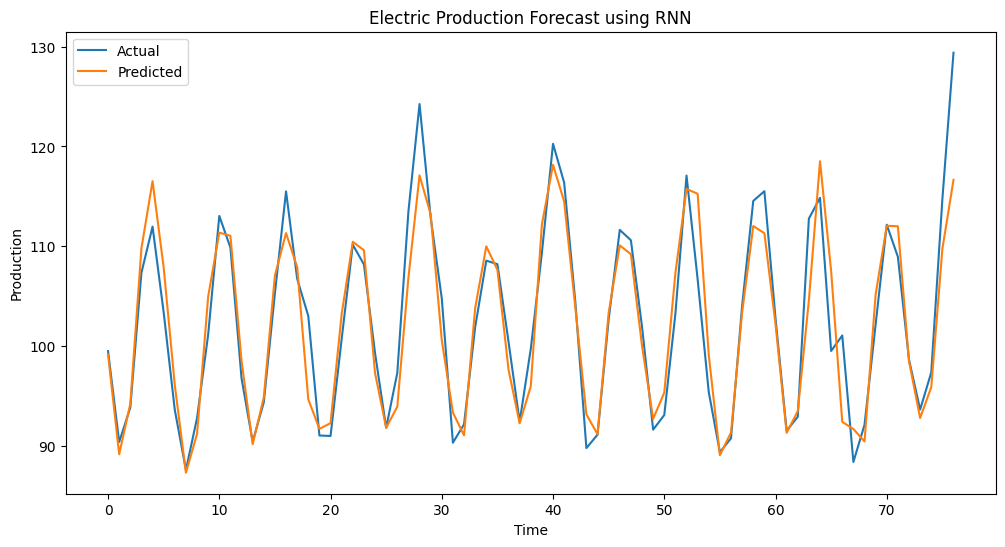

In [19]:
plt.figure(figsize=(12,6))

plt.plot(y_test_actual, label="Actual")
plt.plot(test_predict, label="Predicted")

plt.title("Electric Production Forecast using RNN")
plt.xlabel("Time")
plt.ylabel("Production")
plt.legend()
plt.show()